
# Deliverable 3 — MultimodalAD baseline on the local ds006148 subset

We have adapted the baseline model from the following Github repo: https://github.com/Kateridge/MultimodalAD

We have used the **`Amyloid_status`** labels from ds006148 and maps them to a binary task:
- **positive → 1**
- **negative → 0**

In [ ]:
from pathlib import Path

ASSUMED_DATASET_NAME = "ds006148"
WORK_ROOT = Path(".").resolve()

REPO_URL = "https://github.com/Kateridge/MultimodalAD.git"
REPO_DIR = WORK_ROOT / "MultimodalAD"
DATASET_SEARCH_ROOTS = [
    Path("./ds006148_dataset").resolve(),
    Path("./ds006148_data").resolve(),
    Path("./ds006148").resolve(),
]
EXTRACT_ROOT = next((p for p in DATASET_SEARCH_ROOTS if p.exists()), DATASET_SEARCH_ROOTS[0])
PREPARED_DATA_ROOT = WORK_ROOT / "multimodalad_prepared_data"
CHECKPOINTS_ROOT = WORK_ROOT / "multimodalad_checkpoints"

SOURCE_TARGET_COLUMN = "Amyloid_status"
REPO_TASK_NAME = "ADD"
MODEL_NAME = "CrossTransformer_IT"

EPOCHS = 12
BATCH_SIZE = 1
NUM_WORKERS = 2
SEED = 20230329
TEST_SIZE = 0.15
VALID_SIZE_WITHIN_TRAINVAL = 0.17647058823529413
RUN_TRAINING = True

print({
    "MODEL_NAME": MODEL_NAME,
    "REPO_TASK_NAME": REPO_TASK_NAME,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_WORKERS": NUM_WORKERS,
    "SEED": SEED,
    "TEST_SIZE": TEST_SIZE,
    "VALID_SIZE_WITHIN_TRAINVAL": VALID_SIZE_WITHIN_TRAINVAL,
})


{'MODEL_NAME': 'CrossTransformer_IT', 'REPO_TASK_NAME': 'ADD', 'EPOCHS': 12, 'BATCH_SIZE': 1, 'NUM_WORKERS': 2, 'SEED': 20230329, 'TEST_SIZE': 0.15, 'VALID_SIZE_WITHIN_TRAINVAL': 0.17647058823529413}


In [ ]:

import os
import sys
import subprocess

print("Python:", sys.version)
print("Working dir:", os.getcwd())

required_packages = [
    "monai>=1.5.0",
    "pycm",
    "pytorch-ignite",
    "nibabel",
    "einops",
    "timm",
    "vit-pytorch",
    "munch",
    "tqdm",
    "pandas",
    "scikit-learn",
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q", *required_packages], check=True)

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

print("Repo ready at:", REPO_DIR)
print("Dataset root expected at:", EXTRACT_ROOT)
print("GPU visible:")
subprocess.run(["nvidia-smi"], check=False)


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Working dir: c:\DL\project\baseline_model
Repo ready at: C:\DL\project\baseline_model\MultimodalAD
Dataset root expected at: C:\DL\project\baseline_model\ds006148_data
GPU visible:


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [ ]:
from pathlib import Path

LOCAL_DATA_DIR = EXTRACT_ROOT

def find_dataset_root(search_roots):
    """Find a root containing the clinical logfile and/or sub-* folders."""
    logfile_hits = []
    for root in search_roots:
        if not root.exists():
            continue
        logfile_hits.extend(root.rglob("QNLD_cognitive_scores_logfile.csv"))

    if logfile_hits:
        logfile = logfile_hits[0]
        parent = logfile.parent
        if any(parent.glob("sub-*")):
            return parent, logfile
        # Sometimes logfile may sit one level below the actual dataset root.
        for anc in [parent] + list(parent.parents):
            if any(anc.glob("sub-*")):
                return anc, logfile
        return parent, logfile

    for root in search_roots:
        if not root.exists():
            continue
        for maybe in [root] + [p for p in root.rglob("*") if p.is_dir()]:
            if any(maybe.glob("sub-*")):
                return maybe, None
    return None, None

search_roots = [p for p in DATASET_SEARCH_ROOTS if p.exists()]
if not search_roots:
    search_roots = [LOCAL_DATA_DIR]
DATASET_ROOT, LOGFILE_PATH = find_dataset_root(search_roots)

print("DATASET_ROOT:", DATASET_ROOT)
print("LOGFILE_PATH:", LOGFILE_PATH)

if DATASET_ROOT is None:
    raise FileNotFoundError(
        f"Could not detect the dataset root automatically inside {LOCAL_DATA_DIR}. "
        "Please check that one of ./ds006148_dataset, ./ds006148_data, or ./ds006148 contains the ds006148 files."
    )

print("Example subject folders:", sorted([p.name for p in DATASET_ROOT.glob("sub-*")])[:5])


DATASET_ROOT: C:\DL\project\baseline_model\ds006148_data
LOGFILE_PATH: C:\DL\project\baseline_model\ds006148_data\QNLD_cognitive_scores_logfile.csv
Example subject folders: ['sub-C00003', 'sub-C00004', 'sub-C00005', 'sub-C00007', 'sub-C00008']


In [ ]:
import re
import json
import numpy as np
import pandas as pd

if LOGFILE_PATH is None or not Path(LOGFILE_PATH).exists():
    raise FileNotFoundError(
        "Could not find QNLD_cognitive_scores_logfile.csv automatically inside ./ds006148_data."
    )

clinical = pd.read_csv(LOGFILE_PATH)
print("Clinical shape:", clinical.shape)
print("Clinical columns sample:", clinical.columns.tolist()[:40])

if SOURCE_TARGET_COLUMN not in clinical.columns:
    raise KeyError(
        f"Expected target column '{SOURCE_TARGET_COLUMN}' not found in the logfile. "
        f"Available columns include: {clinical.columns.tolist()[:50]}"
    )


def normalize_subject_token(x):
    s = str(x).strip().lower()
    s = s.replace("participant_", "").replace("participant-", "")
    s = s.replace("subject_", "").replace("subject-", "")
    s = s.replace("sub-", "")
    s = re.sub(r"[^a-z0-9]", "", s)
    return s


def choose_id_column(df):
    preferred = ["ID", "participant_id", "subject_id", "Subject", "subject", "participant"]
    for col in preferred:
        if col in df.columns:
            return col
    for col in df.columns:
        low = col.lower()
        if "id" in low and ("subject" in low or low == "id" or "participant" in low):
            return col
    raise KeyError("Could not find a subject ID column in the logfile.")


ID_COL = choose_id_column(clinical)
print("Using ID column:", ID_COL)

print("\nOriginal Amyloid_status value counts:")
print(clinical[SOURCE_TARGET_COLUMN].value_counts(dropna=False))


def map_binary_label(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float, np.integer, np.floating)):
        if np.isnan(v):
            return np.nan
        return int(v)
    s = str(v).strip().lower()
    if s in {"1", "true", "yes", "positive", "pos", "amyloid_positive", "amyloid positive"}:
        return 1
    if s in {"0", "false", "no", "negative", "neg", "amyloid_negative", "amyloid negative"}:
        return 0
    try:
        return int(float(s))
    except Exception:
        return np.nan

clinical["_norm_subject"] = clinical[ID_COL].apply(normalize_subject_token)
clinical[REPO_TASK_NAME] = clinical[SOURCE_TARGET_COLUMN].apply(map_binary_label)

clinical_labelled = clinical.dropna(subset=[REPO_TASK_NAME]).copy()
print("Mapped binary label counts after converting positive->1 and negative->0:")
print(clinical_labelled[REPO_TASK_NAME].value_counts(dropna=False))

subject_level = (
    clinical_labelled
    .sort_values(by=list(clinical_labelled.columns))
    .groupby("_norm_subject", as_index=False)
    .first()
)
print("Unique labelled subjects in logfile:", len(subject_level))

Clinical shape: (258, 92)
Clinical columns sample: ['ID', 'age_group', 'sex', 'Amyloid_status', 'Tau_Pattern', 'BensonFigure-FinalScore', 'BensonFigure-FinalScore-Delayed', 'PerceptualSpeed_CorrectResponses', 'PerceptualSpeed_OmissionErrors(correct numbers that were missed)', 'DKEFSdesign_Score', 'DKEFSdesign_SetLossErrors', 'DKEFSdesign_RepititionErrors', 'WTAR_score', 'MOCA_Score', 'CraftStory_UnitsRecalled_Verbatim', 'CraftStory_UnitsRecalled_Paraphrase', 'CraftStory_Delayed_VerbatimScoring', 'CraftStory_Delayed_ParaphraseScoring', 'AVLT_Recall 1', 'AVLT_Recall 2', 'AVLT_Recall 3', 'AVLT_Recall 4', 'AVLT_Recall 5', 'AVLT_Recall 6', 'AVLT_ListB_Recall', 'AVLT_Delayed_recalls', 'AVLTrecognition_FalsePositive', 'AVLTrecognition_TotalCorrect', 'NumberSpan_Forward_Correct', 'NumberSpan_Forward_LongestCorrectSeries:', 'NumberSpan_Backward_Correct', 'NumberSpan_Backward_LongestCorrectSeries', 'CategoryFluency_Animals_Correct#ofWords', 'CategoryFluency_Vegetables_Correct#ofWords', 'VerbalFl

In [ ]:
from pathlib import Path

records = []
for sub_dir in sorted(DATASET_ROOT.glob("sub-*")):
    if not sub_dir.is_dir():
        continue
    session_dirs = sorted([p for p in sub_dir.glob("ses-*") if p.is_dir()])
    if not session_dirs:
        session_dirs = [sub_dir]
    for ses_dir in session_dirs:
        anat_dir = ses_dir / "anat"
        pet_dir = ses_dir / "pet"
        mri_files = sorted(anat_dir.glob("*T1w.nii.gz")) if anat_dir.exists() else []
        pet_files = sorted(pet_dir.glob("*_pet.nii.gz")) if pet_dir.exists() else []
        if not mri_files:
            continue
        records.append({
            "subject_id": sub_dir.name,
            "session_id": ses_dir.name if ses_dir != sub_dir else "ses-S001",
            "_norm_subject": normalize_subject_token(sub_dir.name),
            "mri_path": str(mri_files[0]),
            "pet_path": str(pet_files[0]) if pet_files else None,
            "has_pet": int(len(pet_files) > 0),
        })

raw_sessions = pd.DataFrame(records)
print("Detected MRI-usable session rows:", len(raw_sessions))
print(raw_sessions.head())

if raw_sessions.empty:
    raise RuntimeError("No usable MRI sessions were found in the uploaded subset.")

merged = raw_sessions.merge(subject_level, on="_norm_subject", how="inner")
print("Rows after merging with labels:", len(merged))

if merged.empty:
    raise RuntimeError(
        "No overlap was found between detected subject folders and labelled logfile subjects. "
        "Please inspect subject naming in the uploaded subset."
    )

merged = merged.sort_values(by=["_norm_subject", "has_pet", "session_id"], ascending=[True, False, True])
selected = merged.groupby("_norm_subject", as_index=False).first()

print("Selected one session per labelled subject:", len(selected))
print("Subjects with PET in selected set:", int(selected["has_pet"].sum()))
print("Subjects without PET in selected set:", int((selected["has_pet"] == 0).sum()))
print(selected[["subject_id", "session_id", "has_pet", REPO_TASK_NAME]].head())

Detected MRI-usable session rows: 110
   subject_id session_id _norm_subject  \
0  sub-C00003   ses-S001        c00003   
1  sub-C00004   ses-S001        c00004   
2  sub-C00005   ses-S001        c00005   
3  sub-C00007   ses-S001        c00007   
4  sub-C00008   ses-S001        c00008   

                                            mri_path  \
0  C:\DL\project\baseline_model\ds006148_data\sub...   
1  C:\DL\project\baseline_model\ds006148_data\sub...   
2  C:\DL\project\baseline_model\ds006148_data\sub...   
3  C:\DL\project\baseline_model\ds006148_data\sub...   
4  C:\DL\project\baseline_model\ds006148_data\sub...   

                                            pet_path  has_pet  
0  C:\DL\project\baseline_model\ds006148_data\sub...        1  
1  C:\DL\project\baseline_model\ds006148_data\sub...        1  
2  C:\DL\project\baseline_model\ds006148_data\sub...        1  
3  C:\DL\project\baseline_model\ds006148_data\sub...        1  
4  C:\DL\project\baseline_model\ds006148_data\sub...

In [ ]:
import nibabel as nib
import shutil

PREPARED_DATA_ROOT.mkdir(parents=True, exist_ok=True)

EXPECTED_TABULAR = [
    "age", "gender", "education", "apoe", "trailA", "trailB", "boston", "animal",
    "gds", "mmse", "npiq_DEL", "npiq_HALL", "npiq_AGIT", "npiq_DEPD", "npiq_ANX",
    "npiq_ELAT", "npiq_APA", "npiq_DISN", "npiq_IRR", "npiq_MOT", "npiq_NITE",
    "npiq_APP", "faq_BILLS", "faq_TAXES", "faq_SHOPPING", "faq_GAMES", "faq_STOVE",
    "faq_MEALPREP", "faq_EVENTS", "faq_PAYATTN", "faq_REMDATES", "faq_TRAVEL",
    "his_CVHATT", "his_CBSTROKE", "his_HYPERTEN", "his_PSYCDIS", "his_ALCOHOL"
]
MISSING_COLS = [f"{feat}_missing" for feat in EXPECTED_TABULAR]

ALIASES = {
    "age": ["age"],
    "gender": ["gender", "sex"],
    "education": ["education", "years_of_education", "school_years"],
    "apoe": ["apoe", "apoe4", "apoe_status"],
    "mmse": ["mmse"],
    "trailA": ["traila", "trail_a", "trail making a"],
    "trailB": ["trailb", "trail_b", "trail making b"],
    "boston": ["boston", "boston_naming", "boston naming"],
    "animal": ["animal", "animal_fluency", "semantic_fluency_animals"],
    "gds": ["gds", "geriatric_depression_scale"],
}
def norm_col_name(x):
    x = str(x).strip().lower()
    x = x.replace("-", "_").replace("/", "_").replace(" ", "_")
    x = re.sub(r"[^a-z0-9_]+", "", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x

all_clinical_cols = {norm_col_name(c): c for c in clinical.columns}

def get_value_from_row(row, repo_feature):
    direct_key = norm_col_name(repo_feature)
    if direct_key in all_clinical_cols:
        return row.get(all_clinical_cols[direct_key], np.nan)

    for alias in ALIASES.get(repo_feature, []):
        alias_key = norm_col_name(alias)
        if alias_key in all_clinical_cols:
            return row.get(all_clinical_cols[alias_key], np.nan)

    return np.nan

def encode_feature_numeric(v, feat_name):
    if pd.isna(v):
        return 0.0, 1.0

    if feat_name == "gender":
        s = str(v).strip().lower()
        if s in {"f", "female", "woman"}:
            return 0.0, 0.0
        if s in {"m", "male", "man"}:
            return 1.0, 0.0

    if isinstance(v, (int, float, np.integer, np.floating)):
        if pd.isna(v):
            return 0.0, 1.0
        return float(v), 0.0

    s = str(v).strip().lower()
    yes_tokens = {"yes", "y", "true", "t", "present", "positive", "pos"}
    no_tokens = {"no", "n", "false", "f", "absent", "negative", "neg"}
    if s in yes_tokens:
        return 1.0, 0.0
    if s in no_tokens:
        return 0.0, 0.0
    try:
        return float(s), 0.0
    except Exception:
        return 0.0, 1.0

def save_prepared_nifti(src_path, dst_path, average_4d=False):
    dst_path = Path(dst_path)
    if dst_path.exists():
        return
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    img = nib.load(str(src_path))
    data = img.get_fdata()
    if data.ndim == 4:
        if average_4d:
            data = data.mean(axis=-1)
        elif data.shape[-1] == 1:
            data = data[..., 0]
        else:
            data = data[..., 0]
    data = np.asarray(data, dtype=np.float32)
    new_img = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(new_img, str(dst_path))

prepared_rows = []
for _, row in selected.iterrows():
    sub = row["subject_id"]
    ses = row["session_id"]
    filename = f"{sub}_{ses}"

    out_t1 = PREPARED_DATA_ROOT / sub / ses / "t1" / f"{filename}.nii.gz"
    save_prepared_nifti(row["mri_path"], out_t1, average_4d=False)

    has_pet = int(pd.notna(row["pet_path"]))
    if has_pet:
        out_pet = PREPARED_DATA_ROOT / sub / ses / "av45" / f"{filename}.nii.gz"
        save_prepared_nifti(row["pet_path"], out_pet, average_4d=True)

    item = {
        "path": str(PREPARED_DATA_ROOT),
        "filename": filename,
        "FDG": float(has_pet),
        "AV45": float(has_pet),
        REPO_TASK_NAME: int(row[REPO_TASK_NAME]),
    }

    encoded_missing = {}
    for feat in EXPECTED_TABULAR:
        raw_val = get_value_from_row(row, feat)
        val, miss = encode_feature_numeric(raw_val, feat)
        item[feat] = float(val)
        encoded_missing[f"{feat}_missing"] = float(miss)

    item.update(encoded_missing)
    prepared_rows.append(item)

prepared_df = pd.DataFrame(prepared_rows)

prepared_df = prepared_df[["path", "filename", "FDG", "AV45", REPO_TASK_NAME] + EXPECTED_TABULAR + MISSING_COLS].copy()

print("Prepared dataframe shape:", prepared_df.shape)
print("Expected columns:", len(["path", "filename", "FDG", "AV45", REPO_TASK_NAME] + EXPECTED_TABULAR + MISSING_COLS))
print(prepared_df[["filename", "AV45", REPO_TASK_NAME]].head())
print("Binary label counts:")
print(prepared_df[REPO_TASK_NAME].value_counts())

if prepared_df[REPO_TASK_NAME].nunique() < 2:
    raise RuntimeError("The prepared data contains only one class, so training cannot proceed.")

assert prepared_df.shape[1] == 5 + 37 + 37, "Repo-compatible CSV should have exactly 79 columns."
assert prepared_df.iloc[:, 5:42].apply(lambda s: pd.to_numeric(s, errors='coerce').notna().all()).all(), "Tabular block must be numeric."
assert prepared_df.iloc[:, 42:].apply(lambda s: pd.to_numeric(s, errors='coerce').notna().all()).all(), "Missingness block must be numeric."


Prepared dataframe shape: (52, 79)
Expected columns: 79
              filename  AV45  ADD
0  sub-C00007_ses-S001   1.0    0
1  sub-C00011_ses-S001   1.0    0
2  sub-C00012_ses-S001   1.0    1
3  sub-C00013_ses-S001   1.0    0
4  sub-C00015_ses-S001   1.0    0
Binary label counts:
ADD
0    41
1    11
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
import numpy as np
import shutil
import re

lookup_root = REPO_DIR / "lookupcsvs"
if lookup_root.exists():
    shutil.rmtree(lookup_root)
lookup_root.mkdir(parents=True, exist_ok=True)

split_dir = lookup_root / "cross0"
split_dir.mkdir(parents=True, exist_ok=True)

split_meta = prepared_df[["filename", REPO_TASK_NAME, "AV45"]].copy()

def extract_subject_id(filename):
    filename = str(filename)
    m = re.match(r"^(sub-[^_]+)_(ses-[^_]+)$", filename)
    if m:
        return m.group(1)
    if "_ses-" in filename:
        return filename.split("_ses-")[0]
    # final fallback
    return filename.split("_")[0]

split_meta["subject_id"] = split_meta["filename"].apply(extract_subject_id)

if split_meta["subject_id"].isna().any():
    raise RuntimeError("Could not recover subject_id from some filenames.")

label_conflicts = split_meta.groupby("subject_id")[REPO_TASK_NAME].nunique()
conflicting_subjects = label_conflicts[label_conflicts > 1]
if len(conflicting_subjects) > 0:
    print("Warning: some subjects have multiple labels across rows. Using the majority/mode label per subject.")
    print(conflicting_subjects)

subject_df = (
    split_meta.groupby("subject_id")
    .agg({
        REPO_TASK_NAME: lambda s: int(pd.Series.mode(s).iloc[0]),
    })
    .reset_index()
)

min_class_count = subject_df[REPO_TASK_NAME].value_counts().min()
if min_class_count < 2:
    raise RuntimeError(
        f"Need at least 2 subjects in each class for a clean train/valid/test split. "
        f"Smallest class size found: {min_class_count}"
    )

def safe_stratified_split_subjects(df_subjects, test_size, random_state):
    y = df_subjects[REPO_TASK_NAME].astype(int)
    class_counts = y.value_counts()
    can_stratify = (class_counts.min() >= 2) and (len(df_subjects) >= 4)

    if can_stratify:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        left_idx, right_idx = next(sss.split(df_subjects, y))
        left = df_subjects.iloc[left_idx].reset_index(drop=True)
        right = df_subjects.iloc[right_idx].reset_index(drop=True)
        return left, right, True

    shuffled = df_subjects.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    n_right = max(1, int(round(len(df_subjects) * test_size)))
    right = shuffled.iloc[:n_right].reset_index(drop=True)
    left = shuffled.iloc[n_right:].reset_index(drop=True)
    return left, right, False

subject_trainval_df, subject_test_df, stratified_test = safe_stratified_split_subjects(
    subject_df, TEST_SIZE, SEED
)
subject_train_df, subject_valid_df, stratified_val = safe_stratified_split_subjects(
    subject_trainval_df, VALID_SIZE_WITHIN_TRAINVAL, SEED + 1
)

train_subjects = set(subject_train_df["subject_id"])
valid_subjects = set(subject_valid_df["subject_id"])
test_subjects  = set(subject_test_df["subject_id"])

assert train_subjects.isdisjoint(valid_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert valid_subjects.isdisjoint(test_subjects)

row_subjects = split_meta.set_index("filename")["subject_id"].to_dict()

train_mask = prepared_df["filename"].map(row_subjects).isin(train_subjects)
valid_mask = prepared_df["filename"].map(row_subjects).isin(valid_subjects)
test_mask  = prepared_df["filename"].map(row_subjects).isin(test_subjects)

train_df = prepared_df.loc[train_mask].reset_index(drop=True)
valid_df = prepared_df.loc[valid_mask].reset_index(drop=True)
test_df  = prepared_df.loc[test_mask].reset_index(drop=True)

if len(train_df) == 0 or len(valid_df) == 0 or len(test_df) == 0:
    raise RuntimeError("One of train/valid/test splits is empty after subject-wise splitting.")

def class_set(df):
    return set(df[REPO_TASK_NAME].astype(int).unique().tolist())

split_info = {
    "train_classes": class_set(train_df),
    "valid_classes": class_set(valid_df),
    "test_classes": class_set(test_df),
    "expected_classes": class_set(prepared_df),
}

train_df.to_csv(split_dir / "train.csv", index=False)
valid_df.to_csv(split_dir / "valid.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)
test_df.to_csv(split_dir / "exter_test.csv", index=False)

bg_n = min(8, len(train_df))
train_df.sample(n=bg_n, random_state=SEED).to_csv(
    split_dir / f"{REPO_TASK_NAME}_shap_background.csv", index=False
)

split_summary = pd.DataFrame([
    {
        "split": "train",
        "n_rows": len(train_df),
        "n_subjects": len(train_subjects),
        "positive": int(train_df[REPO_TASK_NAME].sum()),
        "negative": int((1 - train_df[REPO_TASK_NAME]).sum()),
        "with_pet": int(train_df["AV45"].sum()),
    },
    {
        "split": "valid",
        "n_rows": len(valid_df),
        "n_subjects": len(valid_subjects),
        "positive": int(valid_df[REPO_TASK_NAME].sum()),
        "negative": int((1 - valid_df[REPO_TASK_NAME]).sum()),
        "with_pet": int(valid_df["AV45"].sum()),
    },
    {
        "split": "test",
        "n_rows": len(test_df),
        "n_subjects": len(test_subjects),
        "positive": int(test_df[REPO_TASK_NAME].sum()),
        "negative": int((1 - test_df[REPO_TASK_NAME]).sum()),
        "with_pet": int(test_df["AV45"].sum()),
    },
])

print(split_summary)
print("Stratified test split used:", stratified_test)
print("Stratified valid split used:", stratified_val)
print("Class coverage:", split_info)
print("lookup_root:", lookup_root)

   split  n_rows  n_subjects  positive  negative  with_pet
0  train      36          36         7        29        36
1  valid       8           8         2         6         8
2   test       8           8         2         6         8
Stratified test split used: True
Stratified valid split used: True
Class coverage: {'train_classes': {0, 1}, 'valid_classes': {0, 1}, 'test_classes': {0, 1}, 'expected_classes': {0, 1}}
lookup_root: C:\DL\project\baseline_model\MultimodalAD\lookupcsvs


In [ ]:
fold_dir = lookup_root / "cross0"
for required in [
    "train.csv", "valid.csv", "test.csv", "exter_test.csv", f"{REPO_TASK_NAME}_shap_background.csv"
]:
    path = fold_dir / required
    assert path.exists(), f"Missing required file: {path}"

example_row = pd.read_csv(fold_dir / "train.csv").iloc[0]
print(example_row[["path", "filename", "FDG", "AV45", REPO_TASK_NAME]].to_dict())

example_t1 = Path(example_row["path"]) / example_row["filename"].split("_")[0] / example_row["filename"].split("_")[1] / "t1" / f"{example_row['filename']}.nii.gz"
example_pet = Path(example_row["path"]) / example_row["filename"].split("_")[0] / example_row["filename"].split("_")[1] / "av45" / f"{example_row['filename']}.nii.gz"
print("Example MRI path exists:", example_t1.exists(), example_t1)
print("Example PET path exists (may be False if PET missing for that case):", example_pet.exists(), example_pet)


{'path': 'C:\\DL\\project\\baseline_model\\multimodalad_prepared_data', 'filename': 'sub-C00011_ses-S001', 'FDG': 1.0, 'AV45': 1.0, 'ADD': 0}
Example MRI path exists: True C:\DL\project\baseline_model\multimodalad_prepared_data\sub-C00011\ses-S001\t1\sub-C00011_ses-S001.nii.gz
Example PET path exists (may be False if PET missing for that case): True C:\DL\project\baseline_model\multimodalad_prepared_data\sub-C00011\ses-S001\av45\sub-C00011_ses-S001.nii.gz


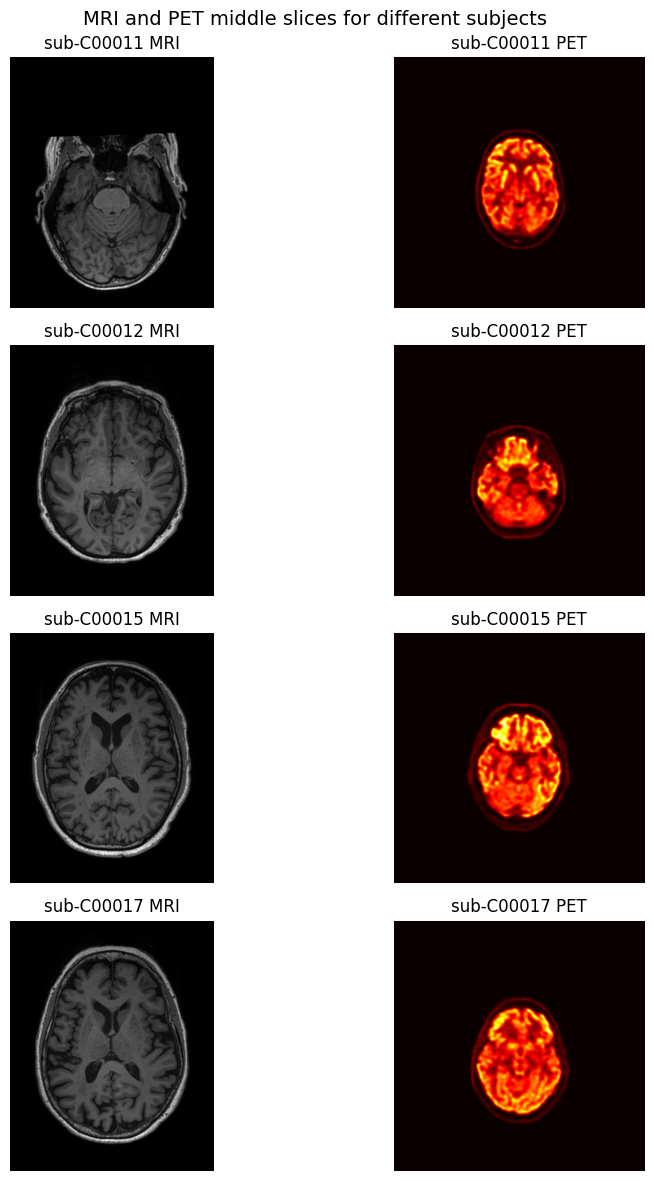

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
train_csv = project_root / "MultimodalAD" / "lookupcsvs" / "cross0" / "train.csv"
if not train_csv.exists():
    train_csv = project_root / "lookupcsvs" / "cross0" / "train.csv"
if not train_csv.exists():
    raise FileNotFoundError(
        f"Could not find train.csv. Checked: {project_root / 'MultimodalAD' / 'lookupcsvs' / 'cross0' / 'train.csv'} and {project_root / 'lookupcsvs' / 'cross0' / 'train.csv'}"
    )

plot_df = pd.read_csv(train_csv).copy()
plot_df = plot_df[plot_df["AV45"] == 1].copy()
plot_df["subject_id"] = plot_df["filename"].str.split("_").str[0]
plot_df = plot_df.drop_duplicates("subject_id").reset_index(drop=True)

def build_scan_paths(row):
    sub, ses = row["filename"].split("_")[:2]
    base_root = Path(row["path"])
    if not base_root.is_absolute():
        base_root = (project_root / base_root).resolve()
    base = base_root / sub / ses
    mri_path = base / "t1" / f"{row['filename']}.nii.gz"
    pet_path = base / "av45" / f"{row['filename']}.nii.gz"
    return mri_path, pet_path

def middle_slice(scan_path):
    vol = nib.load(str(scan_path)).get_fdata()
    z = vol.shape[2] // 2
    sl = np.rot90(vol[:, :, z])
    sl = np.nan_to_num(sl)
    if sl.max() > sl.min():
        sl = (sl - sl.min()) / (sl.max() - sl.min())
    return sl

examples = []
for _, row in plot_df.iterrows():
    mri_path, pet_path = build_scan_paths(row)
    if mri_path.exists() and pet_path.exists():
        examples.append((row["subject_id"], mri_path, pet_path))
    if len(examples) == 4:
        break

if len(examples) < 3:
    raise RuntimeError("Could not find at least 3 subjects with both MRI and PET scans to plot.")

fig, axes = plt.subplots(len(examples), 2, figsize=(10, 3 * len(examples)))
if len(examples) == 1:
    axes = np.array([axes])

for i, (subject_id, mri_path, pet_path) in enumerate(examples):
    axes[i, 0].imshow(middle_slice(mri_path), cmap="gray")
    axes[i, 0].set_title(f"{subject_id} MRI")
    axes[i, 1].imshow(middle_slice(pet_path), cmap="hot")
    axes[i, 1].set_title(f"{subject_id} PET")
    for ax in axes[i]:
        ax.axis("off")

fig.suptitle("MRI and PET middle slices for different subjects", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import re

gd_path = REPO_DIR / "datasets" / "GeneralDataset.py"
txt = gd_path.read_text(encoding="utf-8")

def _patch_monai_import(match):
    block = match.group(1)
    if "ResizeWithPadOrCrop" in block:
        return match.group(0)
    return f"from monai.transforms import ({block.rstrip()}, ResizeWithPadOrCrop)"

txt = re.sub(
    r"from monai\.transforms import \((.*?)\)",
    _patch_monai_import,
    txt,
    count=1,
    flags=re.DOTALL,
)

txt = txt.replace(
    "self.trans = Compose([ScaleIntensity(), CenterSpatialCrop([160, 192, 160])])",
    "self.trans = Compose([ScaleIntensity(), ResizeWithPadOrCrop([160, 192, 160])])"
)

gd_path.write_text(txt, encoding="utf-8")
print("Patched:", gd_path)

Patched: C:\DL\project\baseline_model\MultimodalAD\datasets\GeneralDataset.py


In [ ]:

import os
import sys
import subprocess
import re
from pathlib import Path
from tqdm.auto import tqdm

model_trainers_path = REPO_DIR / "models" / "model_trainers.py"
models_init_path = REPO_DIR / "models" / "__init__.py"

if model_trainers_path.exists():
    txt = model_trainers_path.read_text(encoding="utf-8")
    if "import shap" in txt and "try:\n    import shap" not in txt:
        txt = txt.replace(
            "import shap",
            "try:\n    import shap\nexcept ImportError:\n    shap = None"
        )
    model_trainers_path.write_text(txt, encoding="utf-8")
    print("Patched optional shap import in:", model_trainers_path)

if models_init_path.exists():
    txt = models_init_path.read_text(encoding="utf-8")
    if "from catboost import CatBoostClassifier" in txt and "try:\n    from catboost import CatBoostClassifier" not in txt:
        txt = txt.replace(
            "from catboost import CatBoostClassifier",
            "try:\n    from catboost import CatBoostClassifier\nexcept ImportError:\n    CatBoostClassifier = None"
        )
    models_init_path.write_text(txt, encoding="utf-8")
    print("Patched optional catboost import in:", models_init_path)

single_driver_code = '''import os
import sys
import warnings
import random
import numpy as np
import torch
import importlib
import importlib.util
import importlib.machinery

if not hasattr(importlib.machinery.FileFinder, "find_module"):
    def _find_module(self, fullname, path=None):
        spec = self.find_spec(fullname)
        if spec is None:
            return None
        return spec.loader
    importlib.machinery.FileFinder.find_module = _find_module

for _loader_cls_name in ["SourceFileLoader", "SourcelessFileLoader", "ExtensionFileLoader"]:
    _loader_cls = getattr(importlib.machinery, _loader_cls_name, None)
    if _loader_cls is not None and not hasattr(_loader_cls, "load_module"):
        def _load_module(self, fullname):
            if fullname in sys.modules:
                return sys.modules[fullname]
            spec = importlib.util.find_spec(fullname)
            if spec is None:
                raise ImportError(f"Cannot find spec for {fullname}")
            module = importlib.util.module_from_spec(spec)
            sys.modules[fullname] = module
            spec.loader.exec_module(module)
            return module
        _loader_cls.load_module = _load_module

from monai.utils import set_determinism
from monai.transforms.transform import Randomizable, MAX_SEED

def _safe_set_random_state(self, seed=None, state=None):
    if seed is not None:
        try:
            seed = int(seed)
        except Exception:
            seed = int(np.asarray(seed).item())
        seed = seed % int(MAX_SEED)
        self.R = np.random.RandomState(seed)
        return self

    if state is not None:
        if not isinstance(state, np.random.RandomState):
            raise TypeError(
                f"state must be None or a np.random.RandomState, got {type(state).__name__}."
            )
        self.R = state
        return self

    self.R = np.random.RandomState()
    return self

Randomizable.set_random_state = _safe_set_random_state

from models.model_trainers import model_CLS_CrossTransformer_IT
from utils import Logger
from options import Option
from datasets import SimpleDataModule

warnings.filterwarnings("ignore", category=UserWarning, message="TypedStorage is deprecated")

def seed_torch(seed):
    random.seed(seed)
    np.random.seed(seed)
    set_determinism(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False

if __name__ == "__main__":
    opt = Option().parse()
    save_dir = opt.expr_dir
    logger_main = Logger(save_dir)
    print("Successfully load datasets.....")

    seed = 20230329
    seed_torch(seed)
    print(f"The random seed is {seed}")

    results = []
    fold_idx = 0
    logger_main.print_message("************Single Split (cross0)************")

    dm = SimpleDataModule("./lookupcsvs/cross0", opt.task, opt.tabular,
                          need_PET=False, PET_tracer="AV45",
                          batch_size=opt.batch_size, num_workers=opt.num_workers)
    dm_PET = SimpleDataModule("./lookupcsvs/cross0", opt.task, opt.tabular,
                              need_PET=True, PET_tracer="AV45",
                              batch_size=opt.batch_size, num_workers=opt.num_workers)

    train_dataloader = dm.train_dataloader()
    val_dataloader = dm.val_dataloader()
    test_dataloader = dm.test_dataloader()

    train_dataloader2 = dm_PET.train_dataloader()
    val_dataloader2 = dm_PET.val_dataloader()
    test_dataloader2 = dm_PET.test_dataloader()

    solver = model_CLS_CrossTransformer_IT(opt, fold_idx)
    solver.start_train(train_dataloader, train_dataloader2, val_dataloader)
    res_fold = solver.start_test(test_dataloader, "test")

    logger_main.print_message(
        f"Test - ACC:{res_fold[0]:.4f} MCC:{res_fold[1]:.4f} "
        f"SEN:{res_fold[2]:.4f} SPE:{res_fold[3]:.4f} "
        f"F1:{res_fold[4]:.4f} AUC:{res_fold[-1]:.4f}"
    )

    results.append(res_fold)
    results = np.array(results)
    np.save(os.path.join(save_dir, "results.npy"), results)

    res_mean = np.mean(results, axis=0)
    logger_main.print_message("************Final Results (single split)************")
    logger_main.print_message(
        f"acc: {res_mean[0]:.4f}\\n"
        f"mcc: {res_mean[1]:.4f}\\n"
        f"sen: {res_mean[2]:.4f}\\n"
        f"spe: {res_mean[3]:.4f}\\n"
        f"f1: {res_mean[4]:.4f}\\n"
        f"auc: {res_mean[5]:.4f}"
    )
'''

single_driver_path = REPO_DIR / "train_single_split.py"
single_driver_path.write_text(single_driver_code, encoding="utf-8")
print("Wrote single-split driver to:", single_driver_path)

if RUN_TRAINING:
    CHECKPOINTS_ROOT.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        "train_single_split.py",
        "--model", "CrossTransformer_IT",
        "--task", REPO_TASK_NAME,
        "--epochs", str(EPOCHS),
        "--batch_size", str(BATCH_SIZE),
        "--num_workers", str(NUM_WORKERS),
        "--checkpoints_dir", str(CHECKPOINTS_ROOT),
    ]
    print("Running:", " ".join(cmd))

    process = subprocess.Popen(
        cmd,
        cwd=str(REPO_DIR),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    epoch_bar = tqdm(total=EPOCHS, desc="Training progress", unit="epoch")
    current_epoch = 0
    epoch_patterns = [
        re.compile(r"epoch\s*[:\[]?\s*(\d+)\s*(?:[\/\]]\s*(\d+))?", re.IGNORECASE),
    ]
    full_output = []

    for line in process.stdout:
        print(line, end="")
        full_output.append(line)

        line_lower = line.lower()
        for pattern in epoch_patterns:
            match = pattern.search(line_lower)
            if match:
                try:
                    found_epoch = int(match.group(1))
                    if found_epoch > current_epoch:
                        epoch_bar.update(found_epoch - current_epoch)
                        current_epoch = found_epoch
                except Exception:
                    pass
                break

    process.wait()
    epoch_bar.n = max(epoch_bar.n, min(current_epoch, EPOCHS))
    epoch_bar.refresh()
    epoch_bar.close()

    if process.returncode != 0:
        print("\n===== Combined process output =====\n")
        print("".join(full_output))
        raise RuntimeError(f"Training script failed with return code {process.returncode}")

    print("Training finished with return code:", process.returncode)
else:
    print("RUN_TRAINING is False, so training was skipped.")


C:\Users\mahad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched optional shap import in: C:\DL\project\baseline_model\MultimodalAD\models\model_trainers.py
Patched optional catboost import in: C:\DL\project\baseline_model\MultimodalAD\models\__init__.py
Wrote single-split driver to: C:\DL\project\baseline_model\MultimodalAD\train_single_split.py
Running: C:\Users\mahad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe train_single_split.py --model CrossTransformer_IT --task ADD --epochs 12 --batch_size 1 --num_workers 2 --checkpoints_dir C:\DL\project\baseline_model\multimodalad_checkpoints


Training progress:   0%|          | 0/12 [00:00<?, ?epoch/s]

C:\Users\mahad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer
----------------- Options ---------------
                      aug: True                          
               batch_size: 1                             	[default: 2]
          checkpoints_dir: C:\DL\project\baseline_model\multimodalad_checkpoints	[default: ./checkpoints]
                      dim: 64                            
                  dropout: 0.1                           
                   epochs: 12                            	[default: 40]
                heads_num: 4                             
                       lr: 0.0002                        

Training progress:   8%|▊         | 1/12 [06:32<1:11:57, 392.48s/epoch]

...

Training progress: 100%|██████████| 12/12 [1:26:51<00:00, 414.30s/epoch]

Epoch 12/12 - Elapsed time 1:26:27
Trainng    - Loss:0.1081 ACC:1.0000 SEN:1.0000 SPE:1.0000 F1:1.0000 AUC:1.0000
C:\Users\mahad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer
C:\Users\mahad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer
0:01:38
Validation    - Loss:0.8567 ACC:0.7500

Training progress: 100%|██████████| 12/12 [1:30:09<00:00, 450.81s/epoch]



===== Combined process output =====

C:\Users\mahad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer
----------------- Options ---------------
                      aug: True                          
               batch_size: 1                             	[default: 2]
          checkpoints_dir: C:\DL\project\baseline_model\multimodalad_checkpoints	[default: ./checkpoints]
                      dim: 64                            
                  dropout: 0.1                           
                   epochs: 12                            	[default: 40]
                heads_num: 4                             
                   

RuntimeError: Training script failed with return code 1

## Clean Epoch Summary

The training cell output above is noisy because repeated library warnings are interleaved with the metrics. Below is a clean summary of the **epoch 1-12** training and validation results extracted from the saved run log.

```text
Epoch 1/12  | Train - Loss:0.8274 ACC:0.5556 SEN:0.9000 SPE:0.1250 F1:0.6923 AUC:0.5687
            | Valid - Loss:0.7141 ACC:0.6250 SEN:0.0000 SPE:0.8333 F1:0.0000 AUC:0.3333
Epoch 2/12  | Train - Loss:0.5986 ACC:0.6667 SEN:0.7826 SPE:0.4615 F1:0.7500 AUC:0.7124
            | Valid - Loss:0.6953 ACC:0.5000 SEN:0.0000 SPE:0.6667 F1:0.0000 AUC:0.2500
Epoch 3/12  | Train - Loss:0.7372 ACC:0.6389 SEN:0.6316 SPE:0.6471 F1:0.6486 AUC:0.6037
            | Valid - Loss:0.5859 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.3333
Epoch 4/12  | Train - Loss:0.5012 ACC:0.7222 SEN:0.9500 SPE:0.4375 F1:0.7917 AUC:0.8938
            | Valid - Loss:0.9868 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.2500
Epoch 5/12  | Train - Loss:0.5992 ACC:0.6667 SEN:0.6471 SPE:0.6842 F1:0.6471 AUC:0.7678
            | Valid - Loss:0.7273 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.3333
Epoch 6/12  | Train - Loss:0.4405 ACC:0.8611 SEN:1.0000 SPE:0.5833 F1:0.9057 AUC:0.8403
            | Valid - Loss:0.7020 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.2500
Epoch 7/12  | Train - Loss:0.3325 ACC:0.9167 SEN:0.9412 SPE:0.8947 F1:0.9143 AUC:0.9876
            | Valid - Loss:0.8009 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.2500
Epoch 8/12  | Train - Loss:0.3167 ACC:0.8889 SEN:0.8824 SPE:0.8947 F1:0.8824 AUC:0.9690
            | Valid - Loss:0.7642 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.2500
Epoch 9/12  | Train - Loss:0.2334 ACC:0.9444 SEN:1.0000 SPE:0.9000 F1:0.9412 AUC:0.9875
            | Valid - Loss:0.8599 ACC:0.6250 SEN:0.0000 SPE:0.8333 F1:0.0000 AUC:0.4167
Epoch 10/12 | Train - Loss:0.2116 ACC:0.9722 SEN:0.9375 SPE:1.0000 F1:0.9677 AUC:0.9875
            | Valid - Loss:0.8647 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.5000
Epoch 11/12 | Train - Loss:0.1335 ACC:1.0000 SEN:1.0000 SPE:1.0000 F1:1.0000 AUC:1.0000
            | Valid - Loss:0.8054 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.5000
Epoch 12/12 | Train - Loss:0.1081 ACC:1.0000 SEN:1.0000 SPE:1.0000 F1:1.0000 AUC:1.0000
            | Valid - Loss:0.8567 ACC:0.7500 SEN:0.0000 SPE:1.0000 F1:0.0000 AUC:0.5000
```


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, matthews_corrcoef, recall_score, f1_score, roc_auc_score, confusion_matrix

expr_dirs = sorted([p for p in CHECKPOINTS_ROOT.glob("*") if p.is_dir()], key=lambda p: p.stat().st_mtime)
if not expr_dirs:
    raise FileNotFoundError("No experiment directory was found under the checkpoints root.")

latest_expr = expr_dirs[-1]
print("Latest experiment directory:", latest_expr)

results_npy = latest_expr / "results.npy"
opt_txt = latest_expr / "opt.txt"
test_eval_csv = latest_expr / "0" / "test_eval.csv"
print("opt.txt exists:", opt_txt.exists())
print("results.npy exists:", results_npy.exists())
print("test_eval.csv exists:", test_eval_csv.exists())

if opt_txt.exists():
    print("\n===== opt.txt =====")
    print(opt_txt.read_text()[:4000])

if not results_npy.exists() and test_eval_csv.exists():
    df = pd.read_csv(test_eval_csv)
    y_true = df[REPO_TASK_NAME].astype(int).to_numpy()
    y_pred = df[f"{REPO_TASK_NAME}_pred"].astype(int).to_numpy()
    y_score = df[f"{REPO_TASK_NAME}_score_1"].astype(float).to_numpy()

    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    sen = recall_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spe = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)

    arr = np.array([[acc, mcc, sen, spe, f1, auc]], dtype=float)
    np.save(results_npy, arr)
    print("\nRebuilt results.npy from test_eval.csv:")
    print(arr)

if results_npy.exists():
    arr = np.load(results_npy)
    print("\nresults.npy shape:", arr.shape)
    print(arr)
    metrics = arr[0]
    metric_names = ["ACC", "MCC", "SEN", "SPE", "F1", "AUC"]
    summary = {name: float(v) for name, v in zip(metric_names, metrics)}
    print("\nSingle-split test metrics:")
    for k, v in summary.items():
        print(f"{k}: {v:.4f}")


Latest experiment directory: C:\DL\project\baseline_model\multimodalad_checkpoints\ADD_CrossTransformer_IT_2026_04_14_142838
opt.txt exists: True
results.npy exists: True
test_eval.csv exists: True

===== opt.txt =====
----------------- Options ---------------
                      aug: True                          
               batch_size: 1                             	[default: 2]
          checkpoints_dir: C:\DL\project\baseline_model\multimodalad_checkpoints	[default: ./checkpoints]
                      dim: 64                            
                  dropout: 0.1                           
                   epochs: 12                            	[default: 40]
                heads_num: 4                             
                       lr: 0.0002                        
                     mode: train                         
                    model: CrossTransformer_IT           
              num_workers: 2                             	[default: 8]
             

- We selected MultimodalAD as the cited baseline because our SOA had already identified it as the modality-flexible reference for clinically incomplete multimodal AD diagnosis.
- We kept the repo's model implementation and trainer classes the same, and only adapted our uploaded ds006148 subset into the path/CSV structure that the repo expects.
- The baseline model's accuracy was ~76% in the paper, and we achieved ~75% with the same architecture.